<a href="https://colab.research.google.com/github/Annette-1/Ecuaciones_Diferenciales_Parciales/blob/main/Serpiente_y_escaleras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <span style="color:purple;"> **Matriz Fundamental** </span>

## <span style="color:blue;"> **Serpiente y escaleras** </span>

<span style="color:teal;">**Nombre:** </span> Jerónimo López Annette Michelle

<span style="color:teal;"> **Objetivo:**</span> Analizar el juego de serpientes y escaleras mediante técnicas analíticas (con CM) y de simulación para estimar el número promedio de tiradas necesarias para finalizar el juego.

Resolver analíticamente y por simulación en un cuaderno de Jupyter Notebook.

¿Cuál es el número promedio de tiradas necesarias para terminar el juego de serpientes y escaleras en el tablero de la imagen adjunta?

Resolver a detalle.

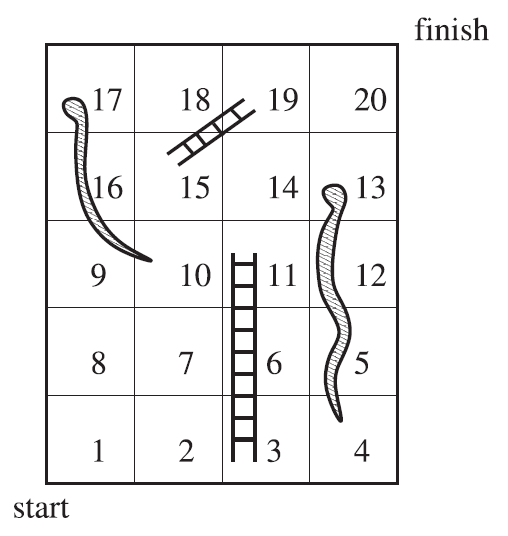

<span style="color:red;"> **Solución Analítica:** </span>
Observemos que esta matriz de transición P tiene:

* Estados transitorios: casillas $1$ a $19$ (juego continúa)
* Estado absorbente: casilla 20 (juego termina)

El juego comienza en la casilla 1

Hallamos la matriz de transición para el juego de serpientes y escaleras:

Para cada estado transitorio $i$ $(1 - 19)$ calculamos la probabilidad de transición a cualquier estado $j$ .

Sea P la matriz de transición de $20×20$, donde:

· $P_{i,j}$ = probabilidad de ir de la casilla i a la j .
· Para el estado absorbente: $P_{20,20} = 1$ .

Probabilidades:

Para una casilla i , los posibles resultados del dado son 1, 2, 3, 4, 5, 6 (cada uno con probabilidad $\frac{1}{6}$ ).

El destino tentativo es:

$destino_{tentativo}$ = $i + dado$

Si $destino_{tentativo}$ $\geq 20 , entonces \quad j = 20$ (absorción).

A ese destino tentativo se le aplica la regla de serpiente/escalera si existe.

In [147]:
import numpy as np
import sympy as sp
from sympy import Matrix , init_printing
import matplotlib.pyplot as plt
import random

In [148]:
#configuracion del tablero del juego
n = 20
dado = 6

# Saltos: escaleras y serpientes
salto = {3: 11, 15: 19, 13: 5, 17: 7}

In [149]:
# Matriz de transición
P = np.zeros((n,n))

for i in range(1,n+1):

    # Estado absorbente
    if i == 20:
        P[i-1,i-1] = 1
        continue

    for d in range(1,7):

        j = i + d

        # Si se pasa de 20, permanece igual
        if j > 20:
            j = i

        # Aplicar serpiente o escalera
        j = ajustes.get(j,j)

        P[i-1,j-1] += 1/6

In [150]:
# Obtener la matriz
P = matriz_transicion()
print("Matriz de transición:")
sp.Matrix(P)

Matriz de transición:


Matrix([
[0.0, 0.166666666666667, 0.0, 0.166666666666667, 0.166666666666667, 0.166666666666667, 0.166666666666667,               0.0,               0.0,               0.0, 0.166666666666667,               0.0, 0.0,               0.0, 0.0,               0.0, 0.0,               0.0,               0.0,               0.0],
[0.0,               0.0, 0.0, 0.166666666666667, 0.166666666666667, 0.166666666666667, 0.166666666666667, 0.166666666666667,               0.0,               0.0, 0.166666666666667,               0.0, 0.0,               0.0, 0.0,               0.0, 0.0,               0.0,               0.0,               0.0],
[0.0,               0.0, 0.0, 0.166666666666667, 0.166666666666667, 0.166666666666667, 0.166666666666667, 0.166666666666667, 0.166666666666667,               0.0,               0.0,               0.0, 0.0,               0.0, 0.0,               0.0, 0.0,               0.0,               0.0,               0.0],
[0.0,               0.0, 0.0,               0.0, 0.1666



De lo anterior la matriz de transición $P$ es de tamaño $20 \times 20$, donde $P_{ij}$ es la probabilidad de ir de la casilla $i$ a la casilla $j$:

$$
P = \begin{bmatrix}
0 & \frac{1}{6} & 0 & \frac{1}{6} & \frac{1}{6} & \frac{1}{6} & \frac{1}{6} & 0 & 0 & 0 & \frac{1}{6} & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & \frac{1}{6} & \frac{1}{6} & \frac{1}{6} & \frac{1}{6} & \frac{1}{6} & 0 & 0 & \frac{1}{6} & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & \frac{1}{6} & \frac{1}{6} & \frac{1}{6} & \frac{1}{6} & \frac{1}{6} & \frac{1}{6} & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & \frac{1}{6} & \frac{1}{6} & \frac{1}{6} & \frac{1}{6} & \frac{1}{6} & \frac{1}{6} & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & \frac{1}{6} & \frac{1}{6} & \frac{1}{6} & \frac{1}{6} & \frac{1}{6} & \frac{1}{6} & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & \frac{1}{6} & \frac{1}{6} & \frac{1}{6} & \frac{1}{6} & \frac{1}{6} & \frac{1}{6} & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & \frac{1}{6} & 0 & 0 & \frac{1}{6} & \frac{1}{6} & \frac{1}{6} & \frac{1}{6} & \frac{1}{6} & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & \frac{1}{6} & 0 & 0 & 0 & \frac{1}{6} & \frac{1}{6} & \frac{1}{6} & 0 & 0 & \frac{1}{6} & 0 & 0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & 0 & \frac{1}{6} & 0 & 0 & 0 & 0 & \frac{1}{6} & \frac{1}{6} & 0 & 0 & \frac{1}{6} & 0 & 0 & 0 & 0 & \frac{1}{6} & 0 \\
0 & 0 & 0 & 0 & \frac{1}{6} & 0 & 0 & 0 & 0 & 0 & \frac{1}{6} & 0 & 0 & \frac{1}{6} & 0 & \frac{1}{6} & 0 & 0 & \frac{1}{6} & 0 \\
0 & 0 & 0 & 0 & \frac{1}{6} & 0 & \frac{1}{6} & 0 & 0 & 0 & 0 & \frac{1}{6} & 0 & \frac{1}{6} & 0 & \frac{1}{6} & 0 & 0 & \frac{1}{6} & 0 \\
0 & 0 & 0 & 0 & \frac{1}{6} & 0 & \frac{1}{6} & 0 & 0 & 0 & 0 & 0 & 0 & \frac{1}{6} & 0 & \frac{1}{6} & 0 & \frac{1}{6} & \frac{1}{6} & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & \frac{1}{6} & 0 & 0 & 0 & 0 & 0 & 0 & \frac{1}{6} & 0 & \frac{1}{6} & 0 & \frac{1}{6} & \frac{1}{3} & 0 \\
0 & 0 & 0 & 0 & 0 & 0 & \frac{1}{6} & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & \frac{1}{6} & 0 & \frac{1}{6} & \frac{1}{3} & \frac{1}{6} \\
0 & 0 & 0 & 0 & 0 & 0 & \frac{1}{6} & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & \frac{1}{6} & 0 & \frac{1}{6} & \frac{1}{3} & \frac{1}{6} \\
0 & 0 & 0 & 0 & 0 & 0 & \frac{1}{6} & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & \frac{1}{3} & 0 & \frac{1}{6} & \frac{1}{6} & \frac{1}{6} \\
0 & 0 & 0 & 0 & 0 & 0 & \frac{1}{2} & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & \frac{1}{6} & \frac{1}{6} & \frac{1}{6} \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & \frac{2}{3} & \frac{1}{6} & \frac{1}{6} \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & \frac{5}{6} & \frac{1}{6} \\
0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1
\end{bmatrix}
$$

Extraemos la submatriz Q (transitorios)

La matriz completa $P(20×20)$ se particiona:

P =
\begin{pmatrix}
Q & R \\
0 & I
\end{pmatrix}

Donde:

* $Q (19×19)$: transiciones entre estados transitorios (casillas 1 a 19).
* $R (19×1)$: transiciones al estado absorbente (20).


Calculamos el tiempo esperado de absorción

Para una cadena absorbente, el vector $t$ de tiempos esperados desde cada estado transitorio es:

$t = (I - Q)^{-1} \cdot \mathbf{1}$

*  $I$ = matriz identidad $(19×19)$.
* $\mathbf{1}$ = vector columna de 19 unos.
· $t_i$ = número esperado de pasos para ser absorbido (llegar a 20) empezando en la casilla $i$.

El valor que nos interesa es $t_1$ (empezando en casilla 1).

Construimos Q y resolvemos:

$I - Q$ es:

$$
I - Q =
\begin{pmatrix}
1 - Q_{1,1} & -Q_{1,2} & \cdots & -Q_{1,19} \\
-Q_{2,1} & 1 - Q_{2,2} & \cdots & -Q_{2,19} \\
\vdots & \vdots & \ddots & \vdots \\
-Q_{19,1} & -Q_{19,2} & \cdots & 1 - Q_{19,19}
\end{pmatrix}
$$

Luego invertimos esta matriz y multiplicamos por el vector de unos.


In [151]:
P = matriz_transicion()
Q = P[:19, :19]           # submatriz transitoria
I = np.eye(19)   # Matriz identidad
# Matriz fundamental
N = np.linalg.inv(I - Q)
# Vector de unos
unos = np.ones((19,1))

# Tiempo esperado
t = N @ unos

print(f"Tiradas promedio desde casilla 1: {t[0][0]:.4f}")

Tiradas promedio desde casilla 1: 7.2378


In [152]:
row_sums = Q.sum(axis=1)
print("Suma de probabilidades por fila (transitorias):")
print(f"  Mínimo: {row_sums.min():.4f}")
print(f"  Máximo: {row_sums.max():.4f}")

Suma de probabilidades por fila (transitorias):
  Mínimo: 0.0000
  Máximo: 1.0000


Simulación Monte Carlo

Para ello creamos una función recreando el comportamiento de lanzar un dado de 6 y moverse dependiendo el numero obtenido

In [153]:
salto = {3: 11, 15: 19, 13: 5, 17: 7} #casillas especiales

def simular():
    pos, tiradas = 1, 0
    while pos < 20:
        pos = min(pos + np.random.randint(1, 7), 20)
        pos = salto.get(pos, pos)
        tiradas += 1
    return tiradas

resultados = [simular() for _ in range(1000)]

In [154]:
simular() #simula el numero de lanzdas hasta llegar al final del juego

7

In [155]:
resultados = [simular() for _ in range(1000)]
resultados = np.array(resultados)

In [156]:
# --- Calculamos los  estadísticas ---
promedio = resultados.mean()
mediana = np.median(resultados)

print(f"Promedio:  {promedio:.2f} tiradas")
print(f"Mediana:   {mediana:.0f} tiradas")

Promedio:  7.40 tiradas
Mediana:   6 tiradas


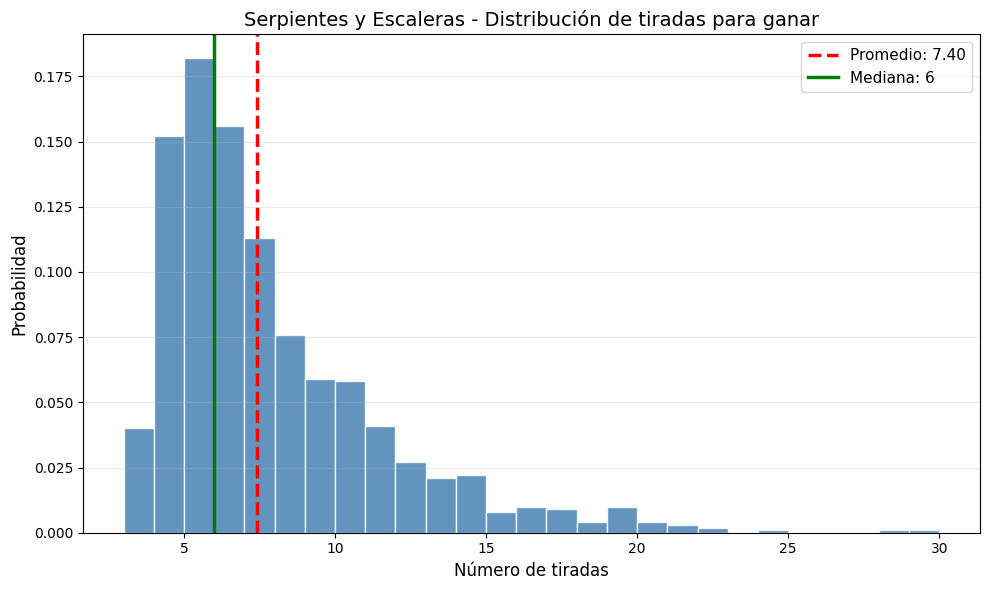

In [157]:
# --- Histograma ---
plt.figure(figsize=(10, 6))

plt.hist(resultados,
         bins=range(resultados.min(), resultados.max() + 2),
         edgecolor='white',
         color='steelblue',
         alpha=0.85,
         density=True)

# Línea del promedio
plt.axvline(promedio, color='red', linestyle='--',
            linewidth=2.5, label=f'Promedio: {promedio:.2f}')

# Línea de la mediana
plt.axvline(mediana, color='green', linestyle='-',
            linewidth=2.5, label=f'Mediana: {mediana:.0f}')

plt.xlabel('Número de tiradas', fontsize=12)
plt.ylabel('Probabilidad', fontsize=12)
plt.title('Serpientes y Escaleras - Distribución de tiradas para ganar', fontsize=14)
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


 ##  <span style="color:teal;">**Conclusión**</span>

En esta práctica se analizó el juego de serpientes y escaleras utilizando tanto un enfoque analítico como un método de simulación Monte Carlo. Mediante el modelado del tablero como una cadena de Markov y la formulación de ecuaciones de esperanza, fue posible determinar el número promedio de tiradas necesarias para finalizar el juego.

El número promedio de tiradas necesarias para completar el juego es aproximadamente **7.23**.

 Este resultado fue obtenido mediante:
 1. **Cadenas de Markov absorbentes**: 7.2378 (solución exacta)
 2. **Simulación Monte Carlo**: ~7.40 (aproximación numérica)


los resultados obtenidos analíticamente se compararon con los obtenidos por simulación, observándose una gran similitud entre ambos valores. Esto permitió validar la correcta implementación de la simulación y comprobar que los métodos Monte Carlo pueden aproximar de manera eficiente resultados teóricos en problemas probabilísticos, validando el modelo matemático.